In [5]:
library(quantmod)
library(forecast)
library(tseries)
library(ggplot2)
library(zoo)
library(astsa)

msft_data <- getSymbols("MSFT", 
                        src = "yahoo", 
                        from = "2020-01-01", 
                        to = Sys.Date(), 
                        auto.assign = FALSE)

preco <- msft_data[, "MSFT.Adjusted"]
preco <- as.numeric(preco)

In [10]:
ts_data <- ts(preco,frequency = 252)

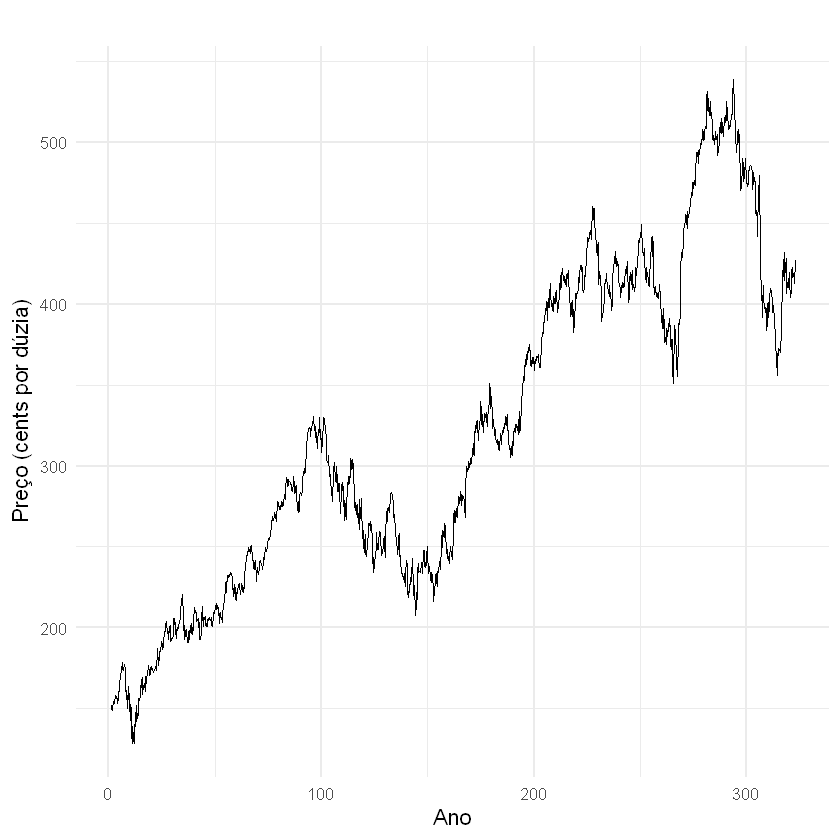

In [9]:
autoplot(ts_data) +
  labs(
    title = "",
    x     = "Ano",
    y     = "Preço (cents por dúzia)"
  ) +
  theme_minimal(base_size = 13)

Warning message:
"Removed 4 rows containing missing values or values outside the scale range
(`geom_line()`)."


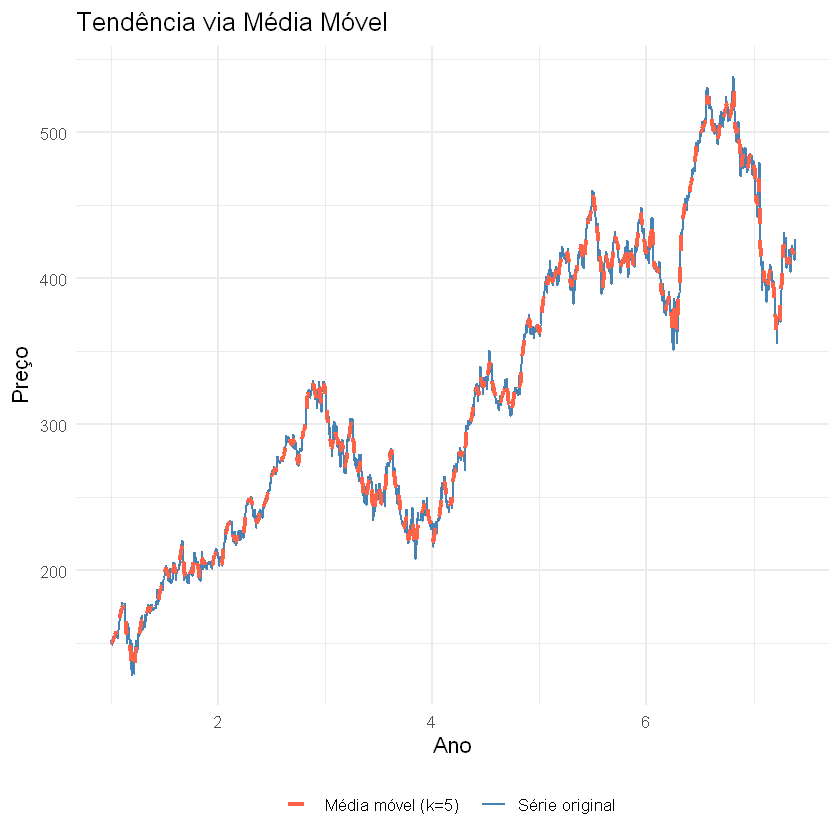

In [13]:
# Média móvel de ordem 5 para suavizar a tendência
library(zoo)
tendencia <- rollmean(ts_data, k = 5, fill = NA)

df_plot <- data.frame(
  ano       = as.numeric(time(ts_data)),
  original  = as.numeric(ts_data),
  tendencia = as.numeric(tendencia)
)

ggplot(df_plot, aes(x = ano)) +
  geom_line(aes(y = original,  color = "Série original"), linewidth = 0.8) +
  geom_line(aes(y = tendencia, color = "Média móvel (k=5)"), linewidth = 1.2, linetype = "dashed") +
  scale_color_manual(values = c("Série original" = "steelblue", "Média móvel (k=5)" = "tomato")) +
  labs(title = "Tendência via Média Móvel", x = "Ano", y = "Preço", color = NULL) +
  theme_minimal(base_size = 13) +
  theme(legend.position = "bottom")

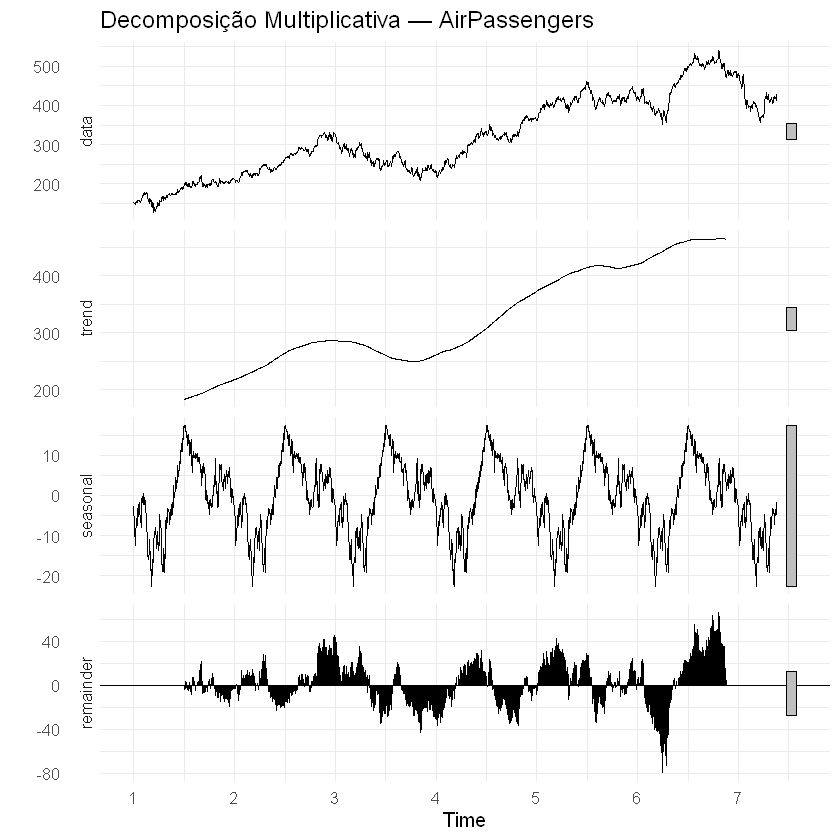

In [14]:
decomp <- decompose(ts_data)
autoplot(decomp) +
  labs(title = "Decomposição Multiplicativa — AirPassengers") +
  theme_minimal(base_size = 12)